# XGBoost + SHAP + individually influences
##### This notebook performs one-by-one feacture sensitivity analysis using XGBoost regression models and SHAP values. It evaluates how each input feature individually influences multiple output variables related to vegetation consumption. It also considers randomness during model training and when calling SHap with a seed between 0 and 10,000.

August 2025, ENLACE

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Model training
from xgboost import XGBRegressor
import shap
# Train-test split and metrics
from sklearn.model_selection import train_test_split

/opt/anaconda3/envs/enlace/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Read the CSV file
# This is the CSV file without wind height
df = pd.read_csv('df_cleaned.csv')
# View the first row to confirm it's loaded correctly
df.iloc[0]

fuel_id                       3023
unit_feature_id                 14
surface_consumed          0.352871
midstory_consumed         0.072806
canopy_consumed           0.038869
fdfm                           0.1
lfm                            0.9
wind_speed                     5.0
wind_direction               345.0
wind_height                   20.0
side_to_start_ignition       right
number_igniters                  3
firing_technique             strip
dash_length               4.571777
gap_length                4.571777
blackline_width           3.047851
spacing_distance          9.143554
igniter_velocity          0.894055
Name: 0, dtype: object

In [3]:
# Inputs and outputs based on dataframe
inputs_list = ['fdfm','lfm','wind_speed','gap_length', 'spacing_distance', 'igniter_velocity','wind_direction'] 

outputs_list = ['surface_consumed', 'midstory_consumed', 'canopy_consumed']


In [4]:
# Number of observations of df
print(len(df))

7886


In [5]:
# Drop rows with missing values in all input columns (no outputs)
columns_to_exclude = ['midstory_consumed', 'canopy_consumed', 'surface_consumed']

# We eliminate 'dash_length' for this analysis,'side_to_start_ignition', 'blackline_width', 'wind_height', 'firing_technique'.
df = df.drop(columns=['dash_length', 'side_to_start_ignition', 'blackline_width', 'wind_height', 'firing_technique'])

# Get all columns except outputs
columns_to_check = [col for col in df.columns if col not in columns_to_exclude]

# Drop rows that have missing values in inputs
df_cleaned = df.dropna(subset=columns_to_check)

In [6]:
# Number of observations of df
print(len(df_cleaned))

6555


In [7]:
# Now, as we'll run the same code for multiple features, let's encapsulate it in two Def
# one for training the model for each feature to analyze, and another Def to plot the results. 

# First Def
def run_xgboost_shap(df_cleaned, inputs_list, outputs_list, selected_feature):
    """
    Trains XGBoost models and computes SHAP values for a specific feature across multiple outputs.
    
    This function performs column-wise analysis by training separate XGBoost models for each output variable,
    using only the selected feature as input. It then computes SHAP values to explain the model's predictions.
    
    Parameters:
    -----------
    df_cleaned : pandas.DataFrame
        Cleaned dataframe containing both input and output variables
    inputs_list : list
        List of all possible input features
    outputs_list : list
        List of output variables to model (canopy, midstore, surface)
    selected_feature : str
        The specific input feature to use for all models
        
    Returns:
    --------
    None (stores results in global variables: models, explainers, shap_values_dict, x_test_dict)
    
    Global Variables Created/Modified:
    --------------------------------
    models : dict
        Dictionary storing trained XGBoost models (key: output name)
    explainers : dict
        Dictionary storing SHAP explainers (key: output name)
    shap_values_dict : dict
        Dictionary storing SHAP values (key: output name)
    x_test_dict : dict
        Dictionary storing test sets (key: output name)
        
    Raises:
    -------
    ValueError
        If the selected_feature is not in inputs_list
    """
    
    # Validate that the selected feature exists in inputs_list
    if selected_feature not in inputs_list:
        raise ValueError(f"The feature '{selected_feature}' is not in the inputs_list.")

    # Declare global variables to store results
    global models, explainers, shap_values_dict, x_test_dict

    # Initialize dictionaries to store results
    models = {}
    explainers = {}
    shap_values_dict = {}
    x_test_dict = {}

    # Set a random seed for reproducibility (same seed used for all splits/models)
    seed = np.random.randint(0, 10000)

    # Train separate models for each output variable
    for output in outputs_list:
        # Filter out rows with missing values for the current output
        df_filtered = df_cleaned.dropna(subset=[output])
        
        # Use only the selected feature as input
        x = df_filtered[[selected_feature]]
        y = df_filtered[output]

        # Print progress information
        print(f"Training model for output: {output} using input: {selected_feature}")
        print(f"Number of records: {len(df_filtered)}")
        
        # Split data into train/test sets (using same seed for all outputs)
        x_train, x_test, y_train, y_test = train_test_split(
            x, y, test_size=0.2, random_state=seed
        )
        
        # Initialize and train XGBoost model
        model = XGBRegressor(
            n_estimators=100, 
            max_depth=4, 
            learning_rate=0.1, 
            random_state=seed
        )
        model.fit(x_train, y_train)

        # Store trained model and test set
        models[output] = model
        x_test_dict[output] = x_test

        # Create SHAP explainer and store it
        explainer = shap.TreeExplainer(model, x_train)
        explainers[output] = explainer

        # Calculate SHAP values and store them
        shap_values = explainer.shap_values(x_test, check_additivity=False)
        shap_values_dict[output] = shap_values

In [8]:
# Second Def
def plotShapValues(shap_values_dict):
    """
    Generates and displays SHAP summary plots for each output variable.
    
    For each output in the global outputs_list, this function:
    1. Calculates feature importance based on mean absolute SHAP values
    2. Prints the feature importance ranking
    3. Creates a SHAP summary plot showing the impact of each feature
    
    Note: Relies on global variables outputs_list and x_test_dict
    
    Parameters:
    -----------
    shap_values_dict : dict
        Dictionary containing SHAP values for each output (from run_xgboost_shap_columnwise)
        Format: {output_name: shap_values_array}
        
    Global Variables Used:
    ---------------------
    outputs_list : list
        List of output variables to process
    x_test_dict : dict
        Dictionary containing test sets for each output (from run_xgboost_shap_columnwise)
        
    Outputs:
    --------
    - Printed feature importance tables for each output
    - SHAP summary plots for each output (displayed and then closed)
    """
    
    # Process each output variable separately
    for output in outputs_list:
        # Retrieve pre-calculated SHAP values and test set for this output
        shap_values = shap_values_dict[output]
        x_test = x_test_dict[output]
        
        # Calculate mean absolute SHAP values as measure of feature importance
        shap_abs_mean = np.abs(shap_values).mean(axis=0)
        
        # Create and display feature importance dataframe
        feature_importance = pd.DataFrame({
            "feature": x_test.columns,          # Feature names
            "importance": shap_abs_mean         # Importance scores
        }).sort_values("importance", ascending=False)  # Sort by importance
        
        print(f"\nFeature importance for output: {output}")
        print(feature_importance)  
        
        # Get features ordered by importance (most important first)
        ordered_features = feature_importance["feature"].tolist()
        
        # Reorder test features and SHAP values by importance
        x_test_sorted = x_test[ordered_features]
        shap_values_sorted = shap_values[:, [x_test.columns.get_loc(f) for f in ordered_features]]
        
        # Generate SHAP summary plot
        print(f"\nGenerating SHAP summary plot for: {output}")
        shap.summary_plot(
            shap_values_sorted, 
            x_test_sorted, 
            show=True
        )
        
        # Close the plot to prevent display issues in notebooks
        plt.close()

Training model for output: surface_consumed using input: fdfm
Number of records: 6555
Training model for output: midstory_consumed using input: fdfm
Number of records: 5412
Training model for output: canopy_consumed using input: fdfm
Number of records: 5412

Feature importance for output: surface_consumed
  feature  importance
0    fdfm    0.060326

Generating SHAP summary plot for: surface_consumed


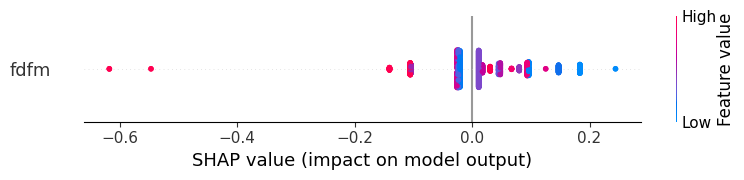


Feature importance for output: midstory_consumed
  feature  importance
0    fdfm    0.061645

Generating SHAP summary plot for: midstory_consumed


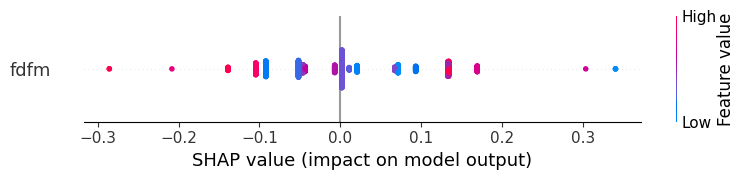


Feature importance for output: canopy_consumed
  feature  importance
0    fdfm     0.01817

Generating SHAP summary plot for: canopy_consumed


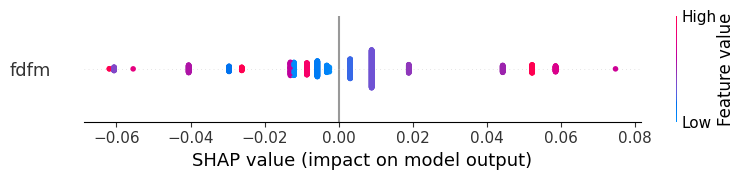

In [9]:
# Here we call the last two Def just for 'fdfm'
run_xgboost_shap(df_cleaned, inputs_list, outputs_list, 'fdfm')
plotShapValues(shap_values_dict)

Training model for output: surface_consumed using input: lfm
Number of records: 6555
Training model for output: midstory_consumed using input: lfm
Number of records: 5412
Training model for output: canopy_consumed using input: lfm
Number of records: 5412

Feature importance for output: surface_consumed
  feature  importance
0     lfm    0.055979

Generating SHAP summary plot for: surface_consumed


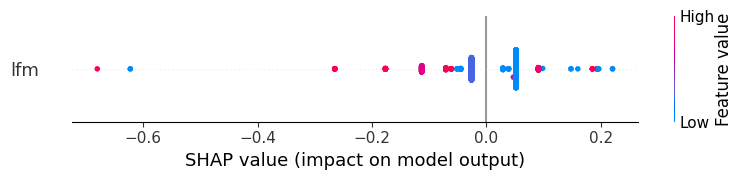


Feature importance for output: midstory_consumed
  feature  importance
0     lfm    0.052349

Generating SHAP summary plot for: midstory_consumed


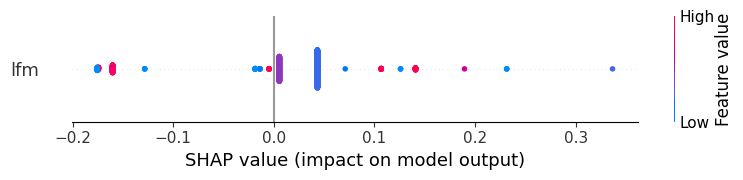


Feature importance for output: canopy_consumed
  feature  importance
0     lfm     0.01767

Generating SHAP summary plot for: canopy_consumed


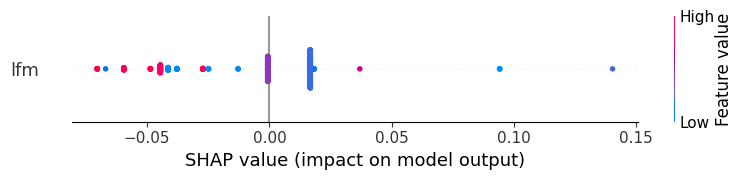

In [10]:
# And here we call the same two Def for 'lfm', you have to change the name of the feature
# you want to analyze individually. 

run_xgboost_shap(df_cleaned, inputs_list, outputs_list, 'lfm')
plotShapValues(shap_values_dict)